# COVID-19 Global Pandemic Analysis

## Project Overview

This project performs Exploratory Data Analysis (EDA) on the COVID-19 dataset published by Our World in Data (OWID).

The objective is to understand:

- Global spread of COVID-19 over time
- Daily case and death trends
- Country-wise impact of the pandemic
- Case Fatality Rate (CFR) analysis
- Population-normalized comparisons
- Continental wave patterns

## Dataset Source

Dataset: Our World in Data (OWID)

The dataset contains:
- Daily confirmed cases
- Daily deaths
- Vaccination statistics
- Population information
- Country and continent level metrics

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

## Project Workflow

1. Data Collection
2. Data Inspection
3. Data Cleaning
4. Missing Value Analysis
5. Global Trend Analysis
6. Case Fatality Rate Analysis
7. Country Comparison
8. Continent-Level Analysis
9. Key Insights

## Step 1: Import Required Libraries

### Libraries Used

- Pandas → Data analysis
- NumPy → Numerical operations
- Matplotlib → Visualization
- Seaborn → Statistical visualization


In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.titlesize'] = 14

## Step 2: Load the Dataset


In [107]:
url = "https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/owid-covid-data.csv"

df = pd.read_csv(url)

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

Shape: (429435, 67)

Columns: ['iso_code', 'continent', 'location', 'date', 'total_cases', 'new_cases', 'new_cases_smoothed', 'total_deaths', 'new_deaths', 'new_deaths_smoothed', 'total_cases_per_million', 'new_cases_per_million', 'new_cases_smoothed_per_million', 'total_deaths_per_million', 'new_deaths_per_million', 'new_deaths_smoothed_per_million', 'reproduction_rate', 'icu_patients', 'icu_patients_per_million', 'hosp_patients', 'hosp_patients_per_million', 'weekly_icu_admissions', 'weekly_icu_admissions_per_million', 'weekly_hosp_admissions', 'weekly_hosp_admissions_per_million', 'total_tests', 'new_tests', 'total_tests_per_thousand', 'new_tests_per_thousand', 'new_tests_smoothed', 'new_tests_smoothed_per_thousand', 'positive_rate', 'tests_per_case', 'tests_units', 'total_vaccinations', 'people_vaccinated', 'people_fully_vaccinated', 'total_boosters', 'new_vaccinations', 'new_vaccinations_smoothed', 'total_vaccinations_per_hundred', 'people_vaccinated_per_hundred', 'people_fully_va

In [108]:
df

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-06,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-07,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,2020-01-08,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,2020-01-09,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
429430,ZWE,Africa,Zimbabwe,2024-07-31,266386.0,0.0,0.0,5740.0,0.0,0.0,...,30.7,36.79,1.7,61.49,0.57,16320539,NaN,NaN,NaN,NaN
429431,ZWE,Africa,Zimbabwe,2024-08-01,266386.0,0.0,0.0,5740.0,0.0,0.0,...,30.7,36.79,1.7,61.49,0.57,16320539,NaN,NaN,NaN,NaN
429432,ZWE,Africa,Zimbabwe,2024-08-02,266386.0,0.0,0.0,5740.0,0.0,0.0,...,30.7,36.79,1.7,61.49,0.57,16320539,NaN,NaN,NaN,NaN
429433,ZWE,Africa,Zimbabwe,2024-08-03,266386.0,0.0,0.0,5740.0,0.0,0.0,...,30.7,36.79,1.7,61.49,0.57,16320539,NaN,NaN,NaN,NaN


# Dataset Data Dictionary

The COVID-19 dataset contains daily pandemic statistics collected from Our World in Data (OWID).

| Column | Description |
|----------|------------|
| date | Reporting date of the observation |
| location | Country or region name |
| iso_code | Unique country/region identifier |
| continent | Continent to which the country belongs |
| population | Total population of the country |
| total_cases | Cumulative confirmed COVID-19 cases |
| new_cases | New confirmed cases reported on that day |
| total_deaths | Cumulative COVID-19 deaths |
| new_deaths | New COVID-19 deaths reported on that day |
| total_vaccinations | Total vaccine doses administered |
| people_vaccinated | Number of people who received at least one vaccine dose |
| people_fully_vaccinated | Number of people fully vaccinated |
| cfr | Case Fatality Rate calculated as (Total Deaths / Total Cases) × 100 |
| deaths_per_million | COVID-19 deaths normalized by population size |

## Step 3: Initial Data Exploration

### Objective

Understand the structure of the dataset before cleaning or analysis.

### What We Check

1. Column names
2. Data types
3. Sample records

### Why This Is Important

Understanding the dataset helps identify:

- Available features
- Data formats
- Potential cleaning requirements

In [109]:
print("Column names:")
print(df.columns.tolist())
print("\nData types (sample):")
print(df.dtypes.head(20))
print("\nFirst 3 rows:")
df.head(3)

Column names:
['iso_code', 'continent', 'location', 'date', 'total_cases', 'new_cases', 'new_cases_smoothed', 'total_deaths', 'new_deaths', 'new_deaths_smoothed', 'total_cases_per_million', 'new_cases_per_million', 'new_cases_smoothed_per_million', 'total_deaths_per_million', 'new_deaths_per_million', 'new_deaths_smoothed_per_million', 'reproduction_rate', 'icu_patients', 'icu_patients_per_million', 'hosp_patients', 'hosp_patients_per_million', 'weekly_icu_admissions', 'weekly_icu_admissions_per_million', 'weekly_hosp_admissions', 'weekly_hosp_admissions_per_million', 'total_tests', 'new_tests', 'total_tests_per_thousand', 'new_tests_per_thousand', 'new_tests_smoothed', 'new_tests_smoothed_per_thousand', 'positive_rate', 'tests_per_case', 'tests_units', 'total_vaccinations', 'people_vaccinated', 'people_fully_vaccinated', 'total_boosters', 'new_vaccinations', 'new_vaccinations_smoothed', 'total_vaccinations_per_hundred', 'people_vaccinated_per_hundred', 'people_fully_vaccinated_per_hun

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-06,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-07,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN


## Step 4: Data Quality Assessment

### Objective

Identify missing values in important COVID-19 metrics.

### Why This Step?

Real-world datasets often contain incomplete information.

Missing values can affect:

- Statistical calculations
- Trend analysis
- Visualizations

In [110]:
df['date'] = pd.to_datetime(df['date'])

key_cols = ['total_cases', 'new_cases', 'total_deaths',
            'new_deaths', 'population', 'continent']

print("Missing values in key columns:")
print(df[key_cols].isnull().sum())
print("\nMissing % :")
print((df[key_cols].isnull().sum() / len(df) * 100).round(2))

Missing values in key columns:
total_cases     17631
new_cases       19276
total_deaths    17631
new_deaths      18827
population          0
continent       26525
dtype: int64

Missing % :
total_cases     4.11
new_cases       4.49
total_deaths    4.11
new_deaths      4.38
population      0.00
continent       6.18
dtype: float64


In [111]:
world_df = df[df['location'] == 'World'].copy()

world_latest = (
    world_df
    .sort_values('date')
    .dropna(subset=['total_cases', 'total_deaths'])
    .iloc[-1]
)

## Step 5: Remove Aggregate Regions

### Objective

Keep only actual countries for country-level analysis.

### Why Is This Necessary?

The OWID dataset includes aggregate entries such as:

- World
- Asia
- Europe
- High Income Countries

These entries are useful for global summaries but can distort country-level calculations.

### Approach

Rows with ISO codes beginning with `OWID` are removed.

### Outcome

The dataset now contains only individual countries.

In [112]:
aggregates = df[df['iso_code'].str.startswith('OWID', na=True)]['location'].unique()
print(f"Removing {len(aggregates)} aggregate rows:")
print(aggregates)

df_countries = df[~df['iso_code'].str.startswith('OWID', na=True)].copy()
print(f"\n Real countries remaining: {df_countries['location'].nunique()}")

Removing 18 aggregate rows:
<StringArray>
[                       'Africa',                          'Asia',
                       'England',                        'Europe',
           'European Union (27)',         'High-income countries',
                        'Kosovo',          'Low-income countries',
 'Lower-middle-income countries',                 'North America',
               'Northern Cyprus',              'Northern Ireland',
                       'Oceania',                      'Scotland',
                 'South America', 'Upper-middle-income countries',
                         'Wales',                         'World']
Length: 18, dtype: str

 Real countries remaining: 237


## Step 6: Select Relevant Features and Handle Missing Values

### Objective

Retain only columns required for the analysis.

### Why This Step?

The original dataset contains dozens of variables, many of which are not needed for this project.

Selecting relevant columns:

- Improves readability
- Reduces memory usage
- Simplifies analysis

### Missing Value Strategy

For daily case and death metrics:

Missing values are replaced with zero because the absence of reported cases on a given day is treated as no recorded cases.

Vaccination columns are intentionally left unchanged because missing vaccination data does not necessarily imply zero vaccinations.

In [113]:
cols = [
    'location', 'continent', 'date', 'population',
    'total_cases', 'new_cases', 'new_cases_smoothed',
    'total_deaths', 'new_deaths', 'new_deaths_smoothed',
    'total_vaccinations', 'people_vaccinated_per_hundred',
    'total_cases_per_million', 'total_deaths_per_million'
]

df_countries = df_countries[cols].copy()

# Fill NaN in numeric cols with 0 — no report on a day = 0 new cases
numeric_fill = ['total_cases', 'total_deaths', 'new_cases', 'new_deaths',
                'new_cases_smoothed', 'new_deaths_smoothed']
df_countries[numeric_fill] = df_countries[numeric_fill].fillna(0)

In [114]:
df_countries.isnull().sum()

location                              0
continent                             0
date                                  0
population                            0
total_cases                           0
new_cases                             0
new_cases_smoothed                    0
total_deaths                          0
new_deaths                            0
new_deaths_smoothed                   0
total_vaccinations               328776
people_vaccinated_per_hundred    332768
total_cases_per_million            5269
total_deaths_per_million           5269
dtype: int64

Vaccination nulls are meaningful nulls. A null in people_vaccinated_per_hundred for March 2020 doesn't mean the data is missing — it means vaccines literally didn't exist yet. If you fill it with 0, that's actually correct by coincidence for early 2020, but it's a lie for a country like Chad that simply never reported vaccination data. You can't tell the difference, so you leave it alone.

# Step 7: Global Trend Analysis

## Objective

Understand how COVID-19 evolved globally over time.

### Questions Answered

- When were major waves observed?
- How did deaths follow case surges?
- What trends become visible after smoothing daily fluctuations?

### Method

Daily cases and deaths are aggregated across all countries.

In [115]:
global_trend = (
    df_countries
    .groupby('date')[['new_cases', 'new_deaths',
                       'new_cases_smoothed', 'new_deaths_smoothed']]
    .sum()
    .reset_index()
)
print(global_trend.head())


        date  new_cases  new_deaths  new_cases_smoothed  new_deaths_smoothed
0 2020-01-01        0.0         0.0                 0.0                  0.0
1 2020-01-02        0.0         0.0                 0.0                  0.0
2 2020-01-03        0.0         0.0                 0.0                  0.0
3 2020-01-04        0.0         0.0                 0.0                  0.0
4 2020-01-05        2.0         3.0                 0.0                  0.0


## Visualizing Global Pandemic Waves

### Why Use Smoothed Curves?

Daily reporting can fluctuate because of:

- Weekend reporting delays
- Data corrections
- Reporting inconsistencies

A 7-day moving average reveals the underlying trend more clearly.

### Interpretation

Peaks indicate major infection waves.

Comparing cases and deaths helps understand the severity of different phases of the pandemic.

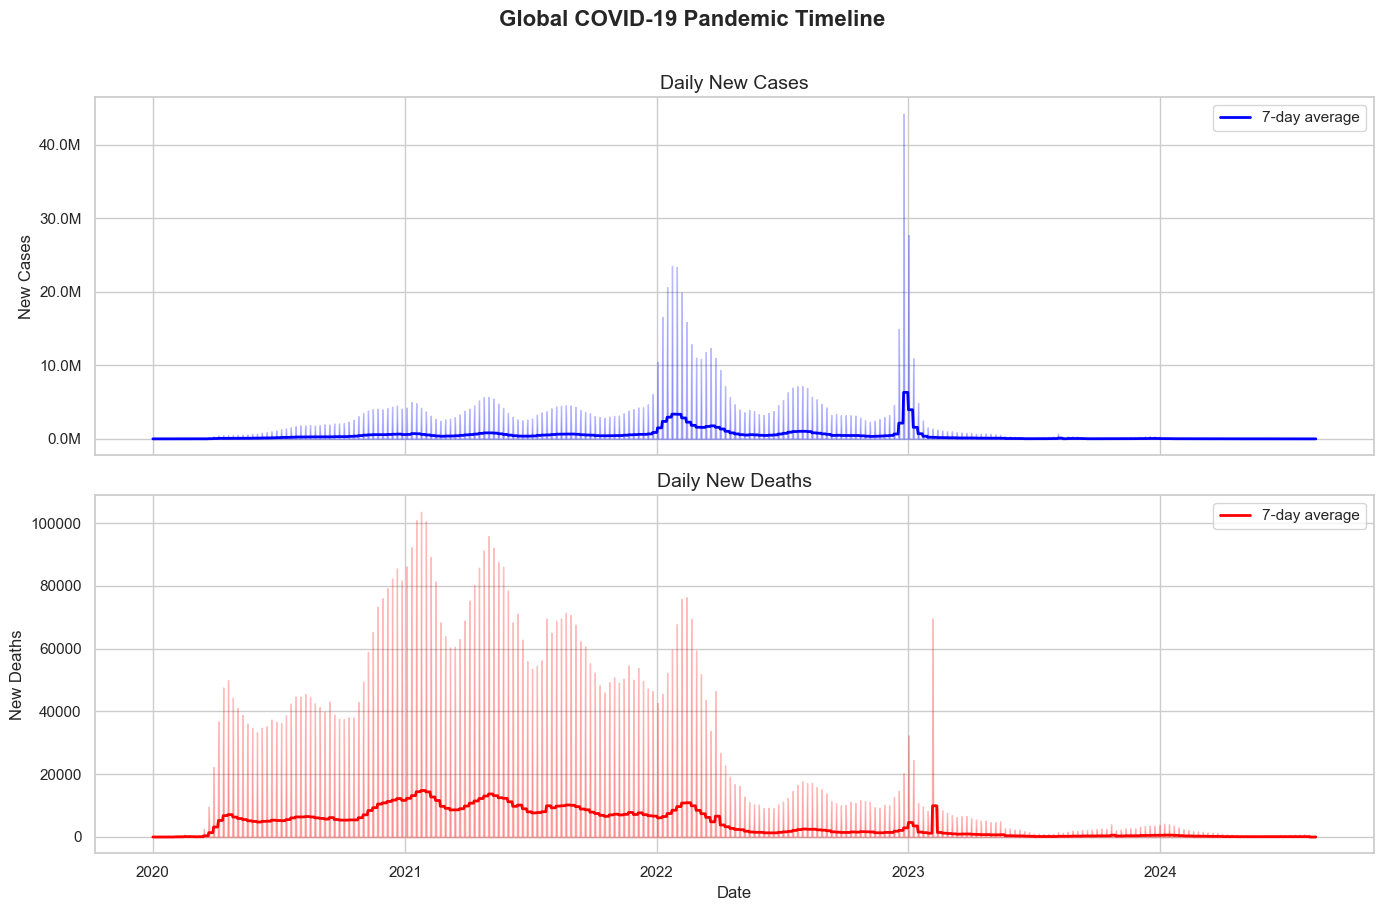

In [116]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
fig.suptitle('Global COVID-19 Pandemic Timeline', fontsize=16, fontweight='bold', y=1.01)

# Cases
axes[0].fill_between(global_trend['date'], global_trend['new_cases'],
                     alpha=0.25, color='blue')
axes[0].plot(global_trend['date'], global_trend['new_cases_smoothed'],
             color='blue', linewidth=2, label='7-day average')
axes[0].set_title('Daily New Cases')
axes[0].set_ylabel('New Cases')
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M'))
axes[0].legend(fontsize=11)


# Deaths
axes[1].fill_between(global_trend['date'], global_trend['new_deaths'],
                     alpha=0.25, color='red')
axes[1].plot(global_trend['date'], global_trend['new_deaths_smoothed'],
             color='red', linewidth=2, label='7-day average')
axes[1].set_title('Daily New Deaths')
axes[1].set_ylabel('New Deaths')

axes[1].set_xlabel('Date')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

### Key Observations

- Death trends generally followed case trends with a slight delay.
- Earlier pandemic waves resulted in larger death surges relative to the number of cases.
- Later waves generated fewer deaths despite high case counts.
- Improvements in healthcare systems, treatments, and vaccination efforts likely contributed to lower mortality.

### Conclusion

While infections remained widespread, the severity of outcomes decreased during later stages of the pandemic.

# Step 8: Case Fatality Rate (CFR) Analysis

## What is CFR?

Case Fatality Rate estimates the percentage of confirmed cases that resulted in death.

:contentReference[oaicite:0]{index=0}

### Why Is CFR Important?

It provides insight into:

- Disease severity
- Healthcare effectiveness
- Testing coverage

### Important Limitation

CFR depends on reported cases and may vary across countries due to differences in testing and reporting practices.

In [117]:
latest = (
    df_countries
    .sort_values('date')
    .groupby('location')
    .last()
    .reset_index()
)

# CFR = total deaths / total cases × 100
latest['cfr'] = (latest['total_deaths'] / latest['total_cases'] * 100).round(2)
latest



,location,continent,date,population,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,total_vaccinations,people_vaccinated_per_hundred,total_cases_per_million,total_deaths_per_million,cfr
0,Afghanistan,Asia,2024-08-04,41128772,235214.0,0.0,0.00,7998.0,0.0,0.0,22964750.0,46.56,5796.47,197.10,3.40
1,Albania,Europe,2024-08-04,2842318,335047.0,0.0,0.00,3605.0,0.0,0.0,3088966.0,47.47,118491.02,1274.93,1.08
2,Algeria,Africa,2024-08-04,44903228,272139.0,18.0,2.57,6881.0,0.0,0.0,15267442.0,17.46,5984.05,151.31,2.53
3,American Samoa,Oceania,2024-08-04,44295,8359.0,0.0,0.00,34.0,0.0,0.0,NaN,NaN,172831.60,702.99,0.41
4,Andorra,Europe,2024-08-04,79843,48015.0,0.0,0.00,159.0,0.0,0.0,157072.0,72.53,602280.44,1994.43,0.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
232,Wallis and Futuna,Oceania,2024-08-04,11596,3760.0,0.0,0.00,9.0,0.0,0.0,18058.0,61.66,326928.10,782.54,0.24
233,Western Sahara,Africa,2022-04-20,576005,0.0,0.0,0.00,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
234,Yemen,Asia,2024-08-04,33696612,11945.0,0.0,0.00,2159.0,0.0,0.0,1298654.0,3.12,312.51,56.48,18.07
235,Zambia,Africa,2024-08-04,20017670,349842.0,18.0,2.57,4077.0,0.0,0.0,13454213.0,58.51,17359.36,202.30,1.17


## Countries with the Highest CFR

### Objective

Identify countries where a larger proportion of confirmed cases resulted in death.

### Filtering Strategy

Countries with fewer than 10,000 cases are excluded.

### Why?

Small case counts can produce misleading CFR values.

### Expected Insight

Countries with high CFR may reflect:

- Severe outbreaks
- Limited testing
- Healthcare system challenges
- Demographic differences

In [118]:
# Filter: only countries with >10k cases (avoids small-sample noise)
latest = latest.dropna(subset=['total_cases', 'total_deaths', 'population'])
latest = latest[latest['total_cases'] > 10000]

print(f"Countries with >10k cases: {len(latest)}")
print("\n📊 Top 10 by CFR:")
print(latest[['location', 'total_cases', 'total_deaths', 'cfr']]
      .sort_values('cfr', ascending=False)
      .head(10)
      .to_string(index=False))

Countries with >10k cases: 195

📊 Top 10 by CFR:
              location  total_cases  total_deaths   cfr
                 Yemen      11945.0        2159.0 18.07
                 Sudan      63993.0        5046.0  7.89
                 Syria      57423.0        3163.0  5.51
               Somalia      27334.0        1361.0  4.98
                  Peru    4526977.0      220975.0  4.88
                 Egypt     516023.0       24830.0  4.81
                Mexico    7619458.0      334551.0  4.39
Bosnia and Herzegovina     403666.0       16392.0  4.06
           Afghanistan     235214.0        7998.0  3.40
               Ecuador    1077445.0       36050.0  3.35


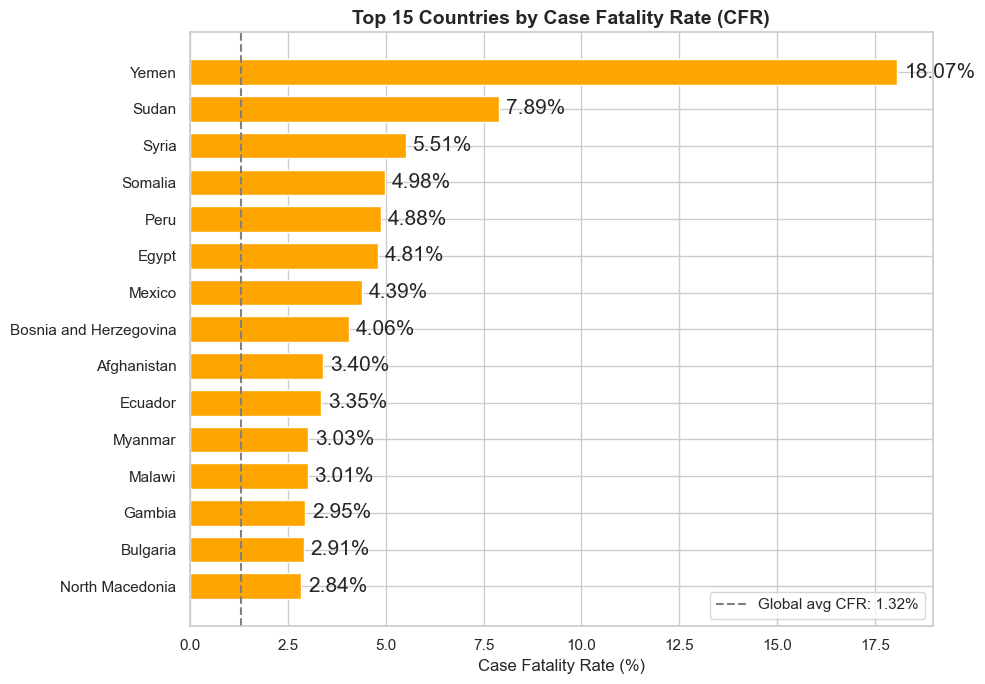

In [119]:
top_cfr = latest.nlargest(15, 'cfr')

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top_cfr['location'][::-1], top_cfr['cfr'][::-1],
               color='orange', edgecolor='white', height=0.7)
ax.bar_label(bars, fmt='%.2f%%', padding=5, fontsize=15)
ax.set_title('Top 15 Countries by Case Fatality Rate (CFR)', fontweight='bold')
ax.set_xlabel('Case Fatality Rate (%)')
ax.axvline(latest['cfr'].mean(), color='gray', linestyle='--', linewidth=1.5,
           label=f"Global avg CFR: {latest['cfr'].mean():.2f}%")
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()


### Key Observations

-Yemen has the highest CFR

# Step 9: Population-Normalized Mortality Analysis

## Why Not Compare Total Deaths?

Countries vary greatly in population size.

Example:

- India has over a billion residents.
- Iceland has only a few hundred thousand.

Direct comparisons are therefore unfair.

## Better Metric

Deaths per million population allows meaningful comparison between countries regardless of size.

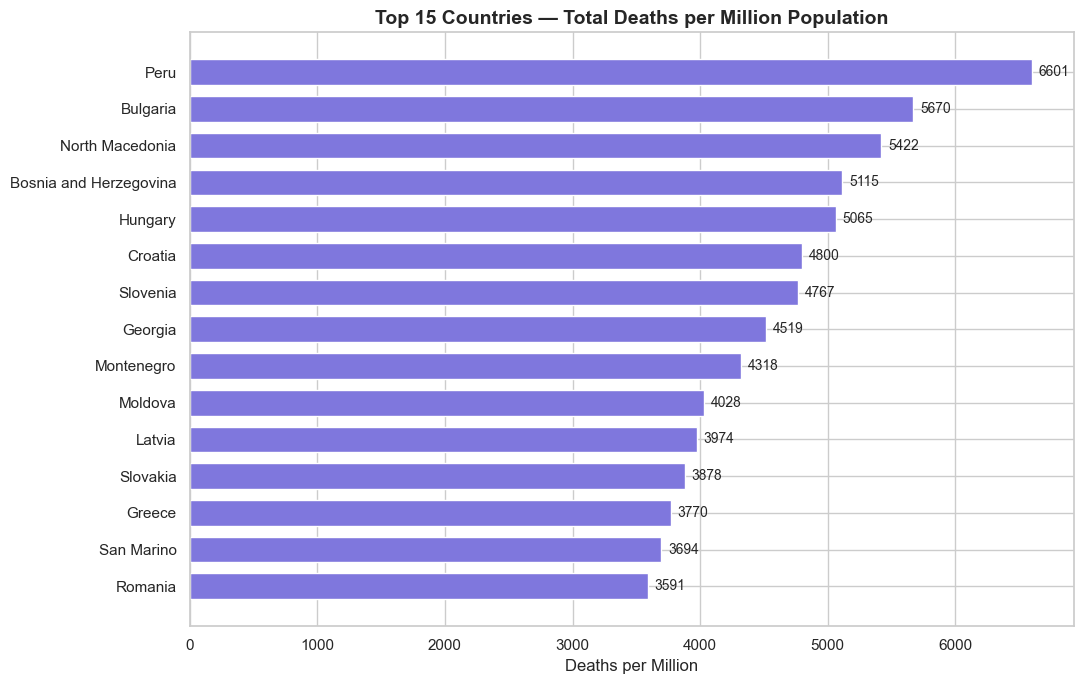

In [120]:
top_dpm = latest.nlargest(15, 'total_deaths_per_million')

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(top_dpm['location'][::-1], top_dpm['total_deaths_per_million'][::-1],
               color='#7F77DD', edgecolor='white', height=0.7)
ax.bar_label(bars, fmt='%.0f', padding=5, fontsize=10)
ax.set_title('Top 15 Countries — Total Deaths per Million Population', fontweight='bold')
ax.set_xlabel('Deaths per Million')
plt.tight_layout()
plt.show()

### Key Observations

- Deaths per million is a more meaningful metric when comparing the relative burden of COVID-19 across countries.
- Some smaller countries experienced extremely high mortality rates relative to their population.
- Large countries may record high total deaths while maintaining lower deaths-per-million values.
- Population-adjusted comparisons provide a fairer assessment of pandemic impact.

### Conclusion
Peru shows highest deaths per Miilion Population 


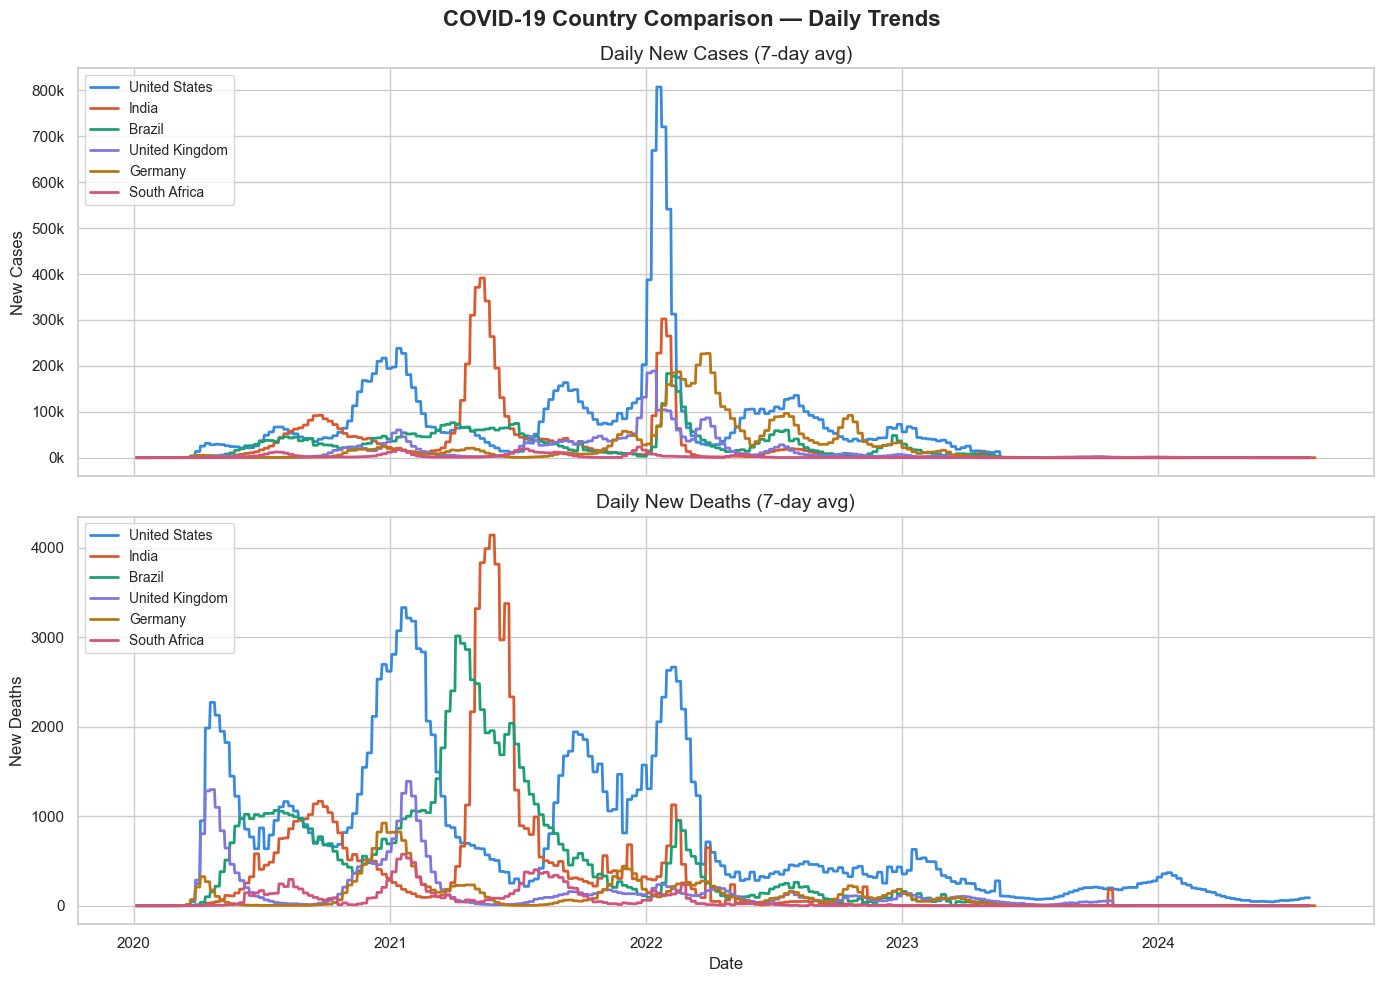

In [121]:
countries = ['United States', 'India', 'Brazil', 'United Kingdom', 'Germany', 'South Africa']
colors    = ['#378ADD', '#D85A30', '#1D9E75', '#7F77DD', '#BA7517', '#D4537E']

subset = df_countries[df_countries['location'].isin(countries)]

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
fig.suptitle('COVID-19 Country Comparison — Daily Trends', fontsize=16, fontweight='bold')

for country, color in zip(countries, colors):
    c = subset[subset['location'] == country]
    axes[0].plot(c['date'], c['new_cases_smoothed'], label=country, color=color, linewidth=2)
    axes[1].plot(c['date'], c['new_deaths_smoothed'], label=country, color=color, linewidth=2)

axes[0].set_title('Daily New Cases (7-day avg)')
axes[0].set_ylabel('New Cases')
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x/1e3:.0f}k'))
axes[0].legend(loc='upper left', fontsize=10, framealpha=0.8)

axes[1].set_title('Daily New Deaths (7-day avg)')
axes[1].set_ylabel('New Deaths')
axes[1].set_xlabel('Date')
axes[1].legend(loc='upper left', fontsize=10, framealpha=0.8)

plt.tight_layout()
plt.show()

# Step 10: Cross-Country Pandemic Comparison

## Objective

Compare COVID-19 trends across major countries.

Countries Selected:

- United States
- India
- Brazil
- United Kingdom
- Germany
- South Africa

### Questions Answered

- Which countries experienced the largest waves?
- How did infection patterns differ?
- How severe were successive outbreaks?

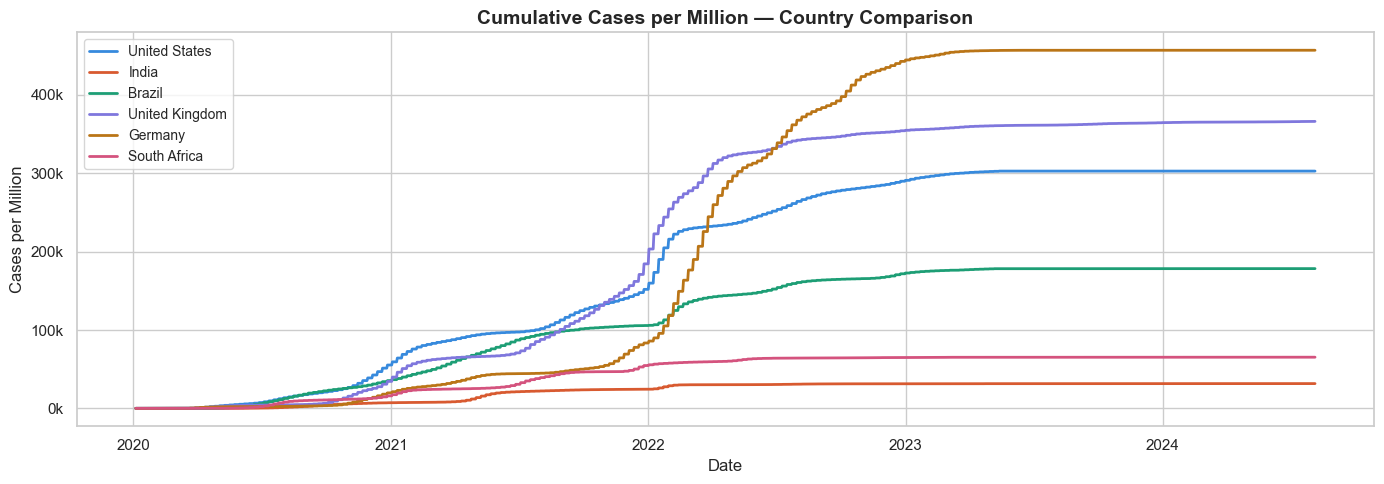

In [122]:
fig, ax = plt.subplots(figsize=(14, 5))
for country, color in zip(countries, colors):
    c = subset[subset['location'] == country]
    ax.plot(c['date'], c['total_cases_per_million'], label=country, color=color, linewidth=2)

ax.set_title('Cumulative Cases per Million — Country Comparison', fontweight='bold')
ax.set_ylabel('Cases per Million')
ax.set_xlabel('Date')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x/1e3:.0f}k'))
ax.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()


### Key Observations

- Countries experienced pandemic waves at different times and with different intensities.
- Several countries experienced multiple distinct waves, indicating recurring outbreaks.
- Differences in public health policies, population size, testing rates, and vaccination campaigns likely contributed to varying patterns.



# Step 11: Continent-Level Wave Analysis

## Objective

Visualize how pandemic waves evolved across continents.

### Why Use a Heatmap?

Heatmaps make it easier to identify:

- Wave timing
- Wave intensity
- Regional similarities

### Normalization

Each continent is scaled relative to its own peak value.

This highlights wave patterns rather than absolute case counts.

### Interpretation

Darker colors represent periods of higher relative transmission.

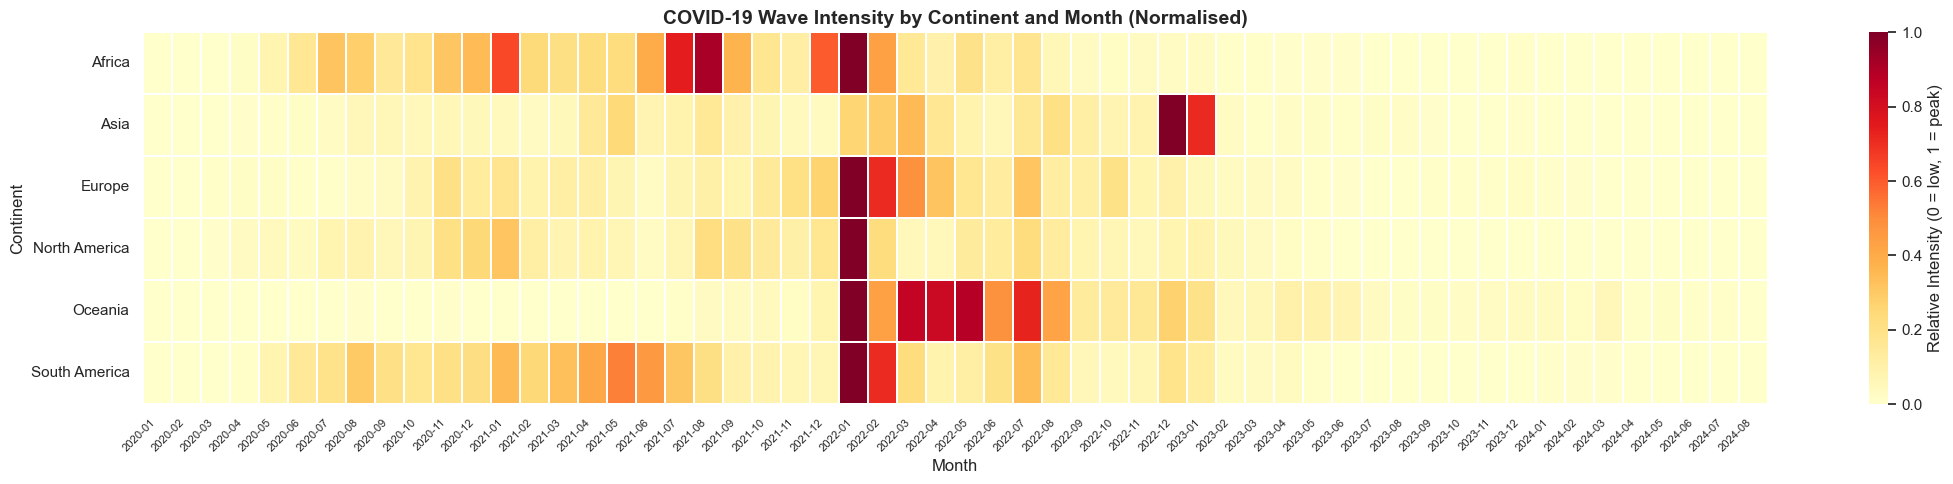

In [123]:
df_cont = df_countries.dropna(subset=['continent']).copy()
df_cont['month'] = df_cont['date'].dt.to_period('M').astype(str)

heatmap_data = (
    df_cont
    .groupby(['continent', 'month'])['new_cases']
    .sum()
    .unstack(fill_value=0)
)

# Normalise each continent to its own max
heatmap_norm = heatmap_data.div(heatmap_data.max(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(22, 5))
sns.heatmap(
    heatmap_norm,
    cmap='YlOrRd',
    ax=ax,
    linewidths=0.3,
    cbar_kws={'label': 'Relative Intensity (0 = low, 1 = peak)'}
)
ax.set_title('COVID-19 Wave Intensity by Continent and Month (Normalised)', fontweight='bold', fontsize=14)
ax.set_xlabel('Month')
ax.set_ylabel('Continent')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()  


### Key Observations

- Most continents experienced their strongest COVID-19 wave during early 2022.
- Asia reached its peak intensity later than most regions, with major outbreaks occurring during late 2022 and early 2023.
- Oceania experienced relatively low transmission during the early pandemic years, followed by a sharp surge in 2022 after restrictions were relaxed.
- South America recorded substantial waves before the global Omicron peak, indicating severe early pandemic impact.
- Africa displayed several moderate waves rather than a single dominant outbreak.
- Pandemic intensity declined across all continents after 2023, suggesting a transition toward endemic COVID-19 conditions.

### Conclusion

The heatmap demonstrates that COVID-19 did not progress uniformly around the world. Different continents experienced waves at different times and intensities.

In [124]:
print("=" * 60)
print("   COVID-19 DATA ANALYSIS — KEY FINDINGS")
print("=" * 60)
print(f"\n  Data up to              : {df['date'].max().date()}")
print(f"  Global total cases      : {world_latest['total_cases']/1e6:.1f} million")
print(f"  Global total deaths     : {world_latest['total_deaths']/1e6:.2f} million")
print(f"  Global CFR              : {world_latest['total_deaths']/world_latest['total_cases']*100:.2f}%")
print(f"\n  Highest CFR country     : {latest.nlargest(1,'cfr')['location'].values[0]}")
print(f"  Most deaths/million     : {latest.nlargest(1,'total_deaths_per_million')['location'].values[0]}")
print(f"  Most total cases        : {latest.nlargest(1,'total_cases')['location'].values[0]}")
print(f"  Most total deaths       : {latest.nlargest(1,'total_deaths')['location'].values[0]}")
print("\n" + "=" * 60)



   COVID-19 DATA ANALYSIS — KEY FINDINGS

  Data up to              : 2024-08-14
  Global total cases      : 775.9 million
  Global total deaths     : 7.06 million
  Global CFR              : 0.91%

  Highest CFR country     : Yemen
  Most deaths/million     : Peru
  Most total cases        : United States
  Most total deaths       : United States

